In [17]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import time

In [2]:
df = pd.read_excel("../data/Telco_customer_churn.xlsx")

df.shape

(7043, 33)

In [3]:
selected_features = [
    'Gender',
    'Senior Citizen',
    'Partner',
    'Dependents',
    'Tenure Months',
    'Internet Service',
    'Contract',
    'Payment Method',
    'Monthly Charges'
]

X = df[selected_features]
y = df['Churn Value']


In [4]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical:", len(categorical_features))
print("Numerical:", len(numerical_features))

Categorical: 7
Numerical: 2


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [7]:
print(categorical_features)
print(numerical_features)

['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Internet Service', 'Contract', 'Payment Method']
['Tenure Months', 'Monthly Charges']


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

/home/msibex/customer-churn-prediction/.venv/lib/python3.8/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [10]:
models = {
    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
}

In [29]:
trained_models = {}
training_times = {}


for name, classifier in models.items():
    
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])
    start = time.perf_counter()
    pipeline.fit(X_train, y_train)
    training_time = time.perf_counter() - start
    training_times[name] = training_time
    trained_models[name] = pipeline

    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Random Forest trained successfully.
XGBoost trained successfully.


In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for name, pipeline in trained_models.items():

    predictions = pipeline.predict(X_test)

    probabilities = pipeline.predict_proba(X_test)[:,1]

    results.append({
    "Model": name,
    "Accuracy": accuracy_score(y_test, predictions),
    "Precision": precision_score(y_test, predictions),
    "Recall": recall_score(y_test, predictions),
    "F1": f1_score(y_test, predictions),
    "ROC-AUC": roc_auc_score(y_test, probabilities),
    "Training Time (s)": round(training_times[name], 3)
    })

In [31]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    "ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s)
0,Logistic Regression,0.791341,0.620482,0.550802,0.583569,0.841546,0.517
2,XGBoost,0.789212,0.615616,0.548128,0.579915,0.835357,1.147
1,Random Forest,0.763662,0.565079,0.475936,0.516691,0.817628,1.500


In [32]:
print(df.shape)

(7043, 33)


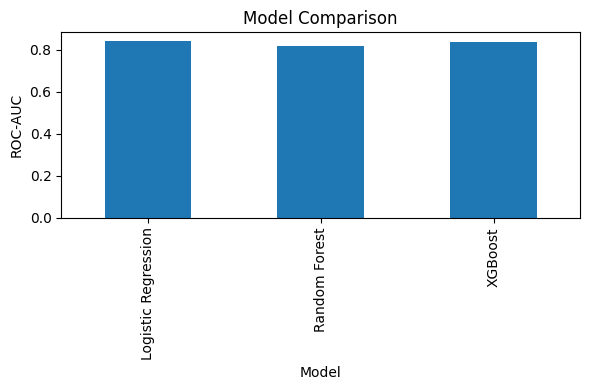

In [33]:
import matplotlib.pyplot as plt

results_df.plot(
    x="Model",
    y="ROC-AUC",
    kind="bar",
    legend=False,
    figsize=(6,4)
)

plt.ylabel("ROC-AUC")
plt.title("Model Comparison")
plt.tight_layout()
plt.show()

In [40]:
import os

print(os.getcwd())

/home/msibex/customer-churn-prediction/notebooks


In [41]:
import joblib

joblib.dump(trained_models["Logistic Regression"],"../src/logistic_model.pkl")

joblib.dump(trained_models["Random Forest"],"../src/random_forest_model.pkl")

joblib.dump(trained_models["XGBoost"],"../src/xgboost_model.pkl")
print("Model saved!")

Model saved!
